In [75]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [76]:
def avg(group, group_size): 
    group['GroupNumber'] = np.array(range(len(group.index))) // group_size
    res = group.groupby('GroupNumber').mean()
    return res
def load_data(group_size,output_range):
    data = pd.read_hdf("../../initialSingleCellDf-channel-20220916-MW_018-001.h5", key="df")
    #print all the columns
    ANTIGENS = ['null', 'E1', 'G4', 'V4', 'T4', 'Q4', 'A2', 'N4']
    data = data.loc[(data.index.get_level_values('CellType') == 'OT-1') & 
                       (data.index.get_level_values('Peptide').isin(ANTIGENS))
                    ]
    data = data.groupby(['Peptide', 'Time', 'Replicate', 'Concentration']).apply(avg, group_size=group_size)
    feature_names = data.columns
    antigen = np.array(data.index.get_level_values('Peptide'))
    concentrations = np.array(data.index.get_level_values('Concentration'))
    #get unique concentrations
    unique_concentrations = list(np.unique(concentrations))
    #index concentrations 
    concentrations = np.array(list(map(lambda x: unique_concentrations.index(x), concentrations)))
    antigen = np.array(list(map(lambda x: ANTIGENS.index(x), antigen)))
    times = np.array(data.index.get_level_values('Time'))
    scaling_factor = 1024/(output_range[1]-output_range[0])
    X = np.array(data.values)/scaling_factor + output_range[0]
    y = np.vstack((antigen,concentrations,times)).T
    return X,y,unique_concentrations,ANTIGENS,feature_names

In [77]:
X,y,concentrations,antigens,feature_names = load_data(100,[-1,1])

In [78]:
print(X.shape,y.shape)
print(concentrations)
print(antigens)

(6093988, 26) (6093988, 3)
['10pM', '1nM', '1uM']
['null', 'E1', 'G4', 'V4', 'T4', 'Q4', 'A2', 'N4']


In [79]:
#create tensor dataset
tensor_x = torch.Tensor(X) # transform to torch tensor

tensor_y = torch.Tensor(y)
my_dataset = torch.utils.data.TensorDataset(tensor_x,tensor_y) # create your datset
train_size = int(0.8 * len(my_dataset))
test_size = len(my_dataset) - train_size
train_dataset, test_dataset = torch.utils.data.random_split(my_dataset, [train_size, test_size])
train_loader = torch.utils.data.DataLoader(train_dataset,batch_size=100,shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset,batch_size=100,shuffle=True)

In [80]:
class Autoencoder(nn.Module):
    def __init__(self,input_size,layer_sizes,embedding_size):
        super(Autoencoder,self).__init__()
        encoder_layers = [nn.Linear(input_size,layer_sizes[0]),nn.ReLU()]
        decoder_layers = [nn.Linear(embedding_size,layer_sizes[-1]),nn.ReLU()]

        for i in range(len(layer_sizes)-1):
            encoder_layers.append(nn.Linear(layer_sizes[i],layer_sizes[i+1]))
            encoder_layers.append(nn.ReLU())
            decoder_layers.append(nn.Linear(layer_sizes[-i-1],layer_sizes[-i-2]))
            decoder_layers.append(nn.ReLU())

        encoder_layers.append(nn.Linear(layer_sizes[-1],embedding_size))
        decoder_layers.append(nn.Linear(layer_sizes[0],input_size))
        
        self.encoder = nn.Sequential(*encoder_layers)
        self.decoder = nn.Sequential(*decoder_layers)        

    def forward(self,x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x
    def encode(self,x):
        return self.encoder(x)


In [81]:
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
model = Autoencoder(26,[250,200,150],2)
model.to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
num_epochs = 10
for epoch in range(num_epochs):
    avg_loss = 0
    model.train()
    for data in train_loader:
        readings = data[0].to(device)
        # ===================forward=====================
        output = model(readings)
        loss = criterion(output, readings)
        # ===================backward====================
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        avg_loss += loss.item()
    #validate
    avg_loss = avg_loss/len(train_loader)
    avg_val_loss = 0
    model.eval()
    with torch.no_grad():
        for data in test_loader:
            readings = data[0].to(device)
            output = model(readings)
            val_loss = criterion(output, readings)
            avg_val_loss += val_loss.item()
    avg_val_loss = avg_val_loss/len(test_loader)

    # ===================log========================
    
    print('epoch [{}/{}], train loss:{:.6f} val loss:{:.6f}'.format(epoch + 1, num_epochs, avg_loss, avg_val_loss))


epoch [1/10], train loss:0.008512 val loss:0.008131
epoch [2/10], train loss:0.007866 val loss:0.007940
epoch [3/10], train loss:0.007803 val loss:0.007624
epoch [4/10], train loss:0.007778 val loss:0.007921
epoch [5/10], train loss:0.007911 val loss:0.008192
epoch [6/10], train loss:0.008199 val loss:0.008573
epoch [7/10], train loss:0.008386 val loss:0.008051
epoch [8/10], train loss:0.008409 val loss:0.008532
epoch [9/10], train loss:0.008636 val loss:0.008535
epoch [10/10], train loss:0.008843 val loss:0.008483


In [82]:
#plot the embeddings of the test set
embeddings = []
markers = []
labels = []
with torch.no_grad():
    for data in test_loader:
        readings = data[0].to(device)
        output = model.encode(readings)
        embeddings.append(output.cpu().numpy())
        labels.append(data[1].numpy())
        markers.append(data[0].numpy())
embeddings = np.vstack(embeddings)
labels = np.vstack(labels)
markers = np.vstack(markers)

In [83]:
print(embeddings.shape,labels.shape,markers.shape)


(1218798, 2) (1218798, 3) (1218798, 26)


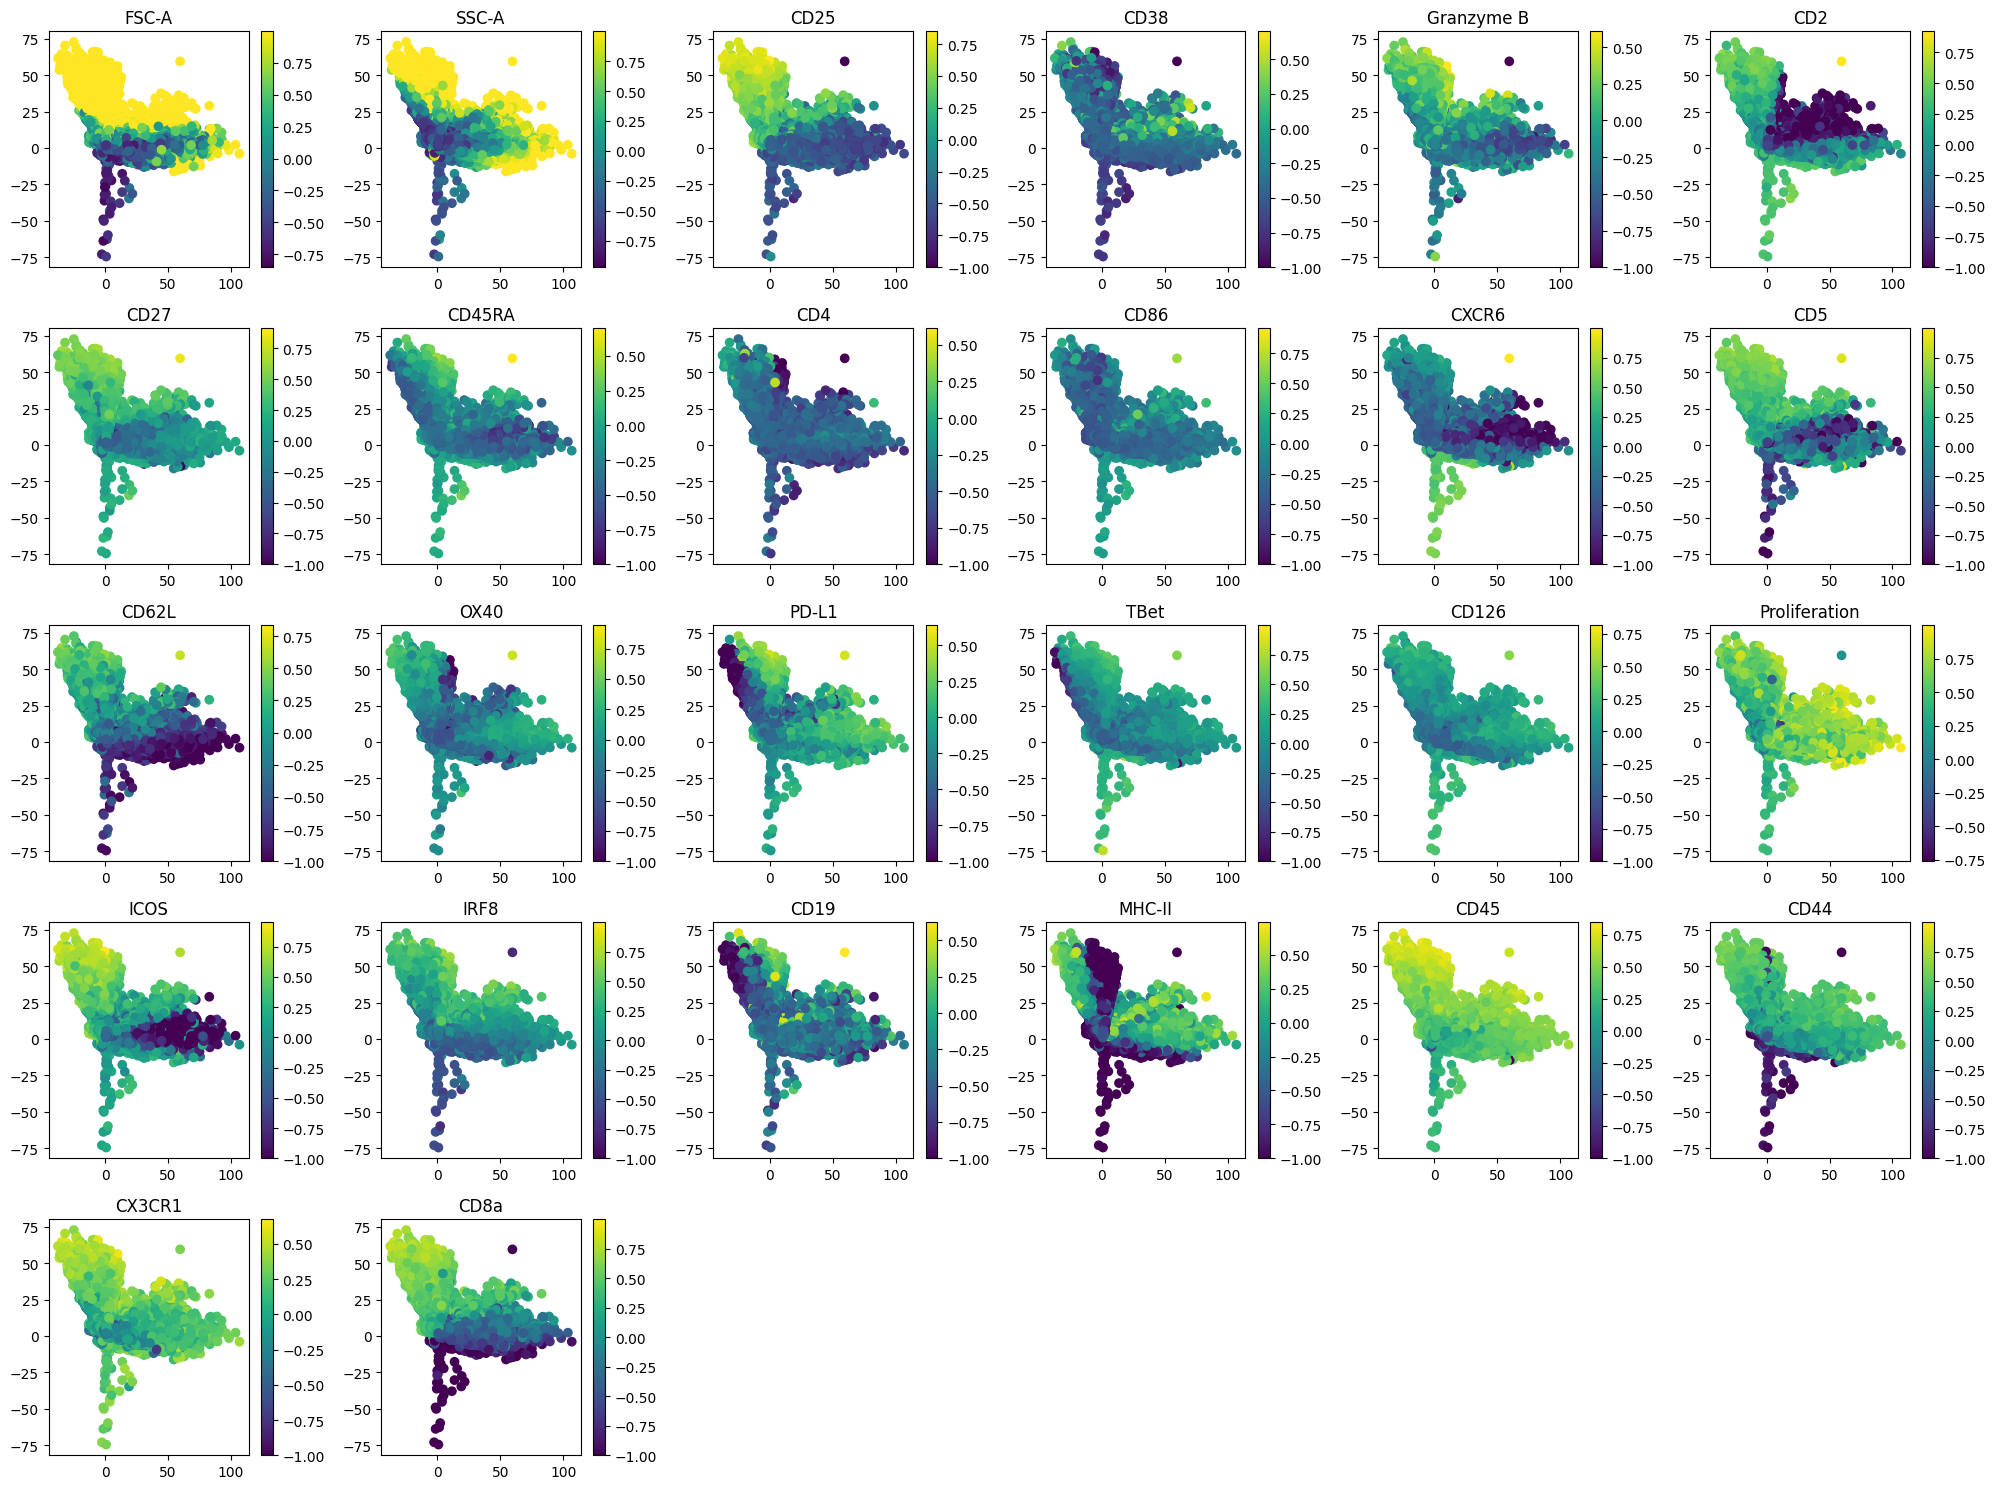

In [84]:
#plot each marker value within the embedding
plt.figure(figsize=(20,15))
for i in range(26):
    plt.subplot(5,6,i+1)
    plt.scatter(embeddings[:,0],embeddings[:,1],c=markers[:,i])
    plt.title(feature_names[i])
    plt.colorbar()
plt.tight_layout()
plt.show()

['null', 'E1', 'G4', 'V4', 'T4', 'Q4', 'A2', 'N4']


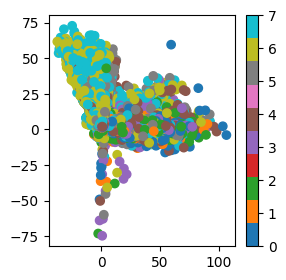

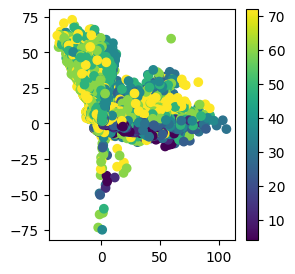

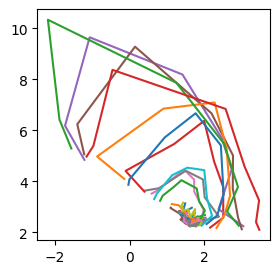

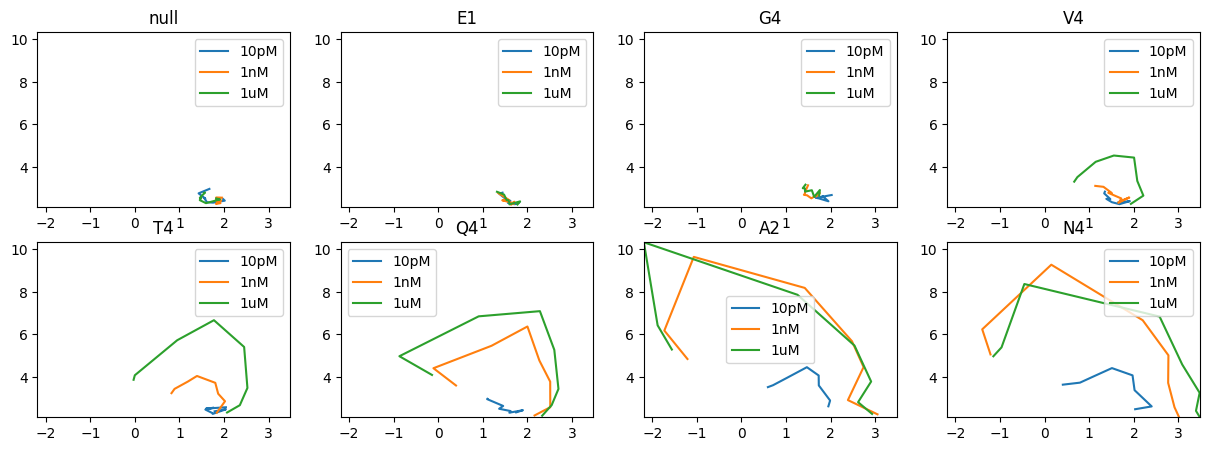

In [85]:
#plot the embeddings
plt.figure(figsize=(3,3))
#plot unique color for each antigen
plt.scatter(embeddings[:,0],embeddings[:,1],c=labels[:,0],cmap='tab10')
#add legend
print(antigens)
plt.colorbar()
plt.show()
#plot unique color for time
plt.figure(figsize=(3,3))
plt.scatter(embeddings[:,0],embeddings[:,1],c=labels[:,2])
plt.colorbar()
plt.show()
#plot a line for each concentration,antigen over time
plt.figure(figsize=(3,3))

df = pd.DataFrame(data=embeddings,columns=['x','y'])
df['antigen'] = labels[:,0]
df['concentration'] = labels[:,1]
df['time'] = labels[:,2]

#group by time,antigen,concentration and average
df = df.groupby(['time','antigen','concentration']).mean().reset_index()

#plot a line for each concentration,antigen over time by using the df
for i in range(len(concentrations)):
    for j in range(len(antigens)):
        df2 = df.loc[(df['concentration'] == i) & (df['antigen'] == j)]
        plt.plot(df2['x'],df2['y'])
plt.show()

#create a new sub plot for each antigen
plt.figure(figsize=(15,5))
#get x and y range of the embeddings
x_min,x_max = df['x'].min(),df['x'].max()
y_min,y_max = df['y'].min(),df['y'].max()
for i in range(len(antigens)):
    plt.subplot(2,4,i+1)
    for j in range(len(concentrations)):
        
        df2 = df.loc[(df['concentration'] == j) & (df['antigen'] == i)]
        plt.plot(df2['x'],df2['y'])
        #plot a dot at the start of the line
        
    plt.xlim(x_min,x_max)
    plt.ylim(y_min,y_max)
    plt.title(antigens[i])
    plt.legend(concentrations)
plt.show()


In [86]:
#plot the reconstruction correlation of each feature

reconstructions = []
initial_readings = []
with torch.no_grad():
    for data in test_loader:
        readings = data[0].to(device)
        output = model(readings)
        reconstructions.append(output.cpu().numpy())
        initial_readings.append(readings.cpu().numpy())
reconstructions = np.vstack(reconstructions)
initial_readings = np.vstack(initial_readings)


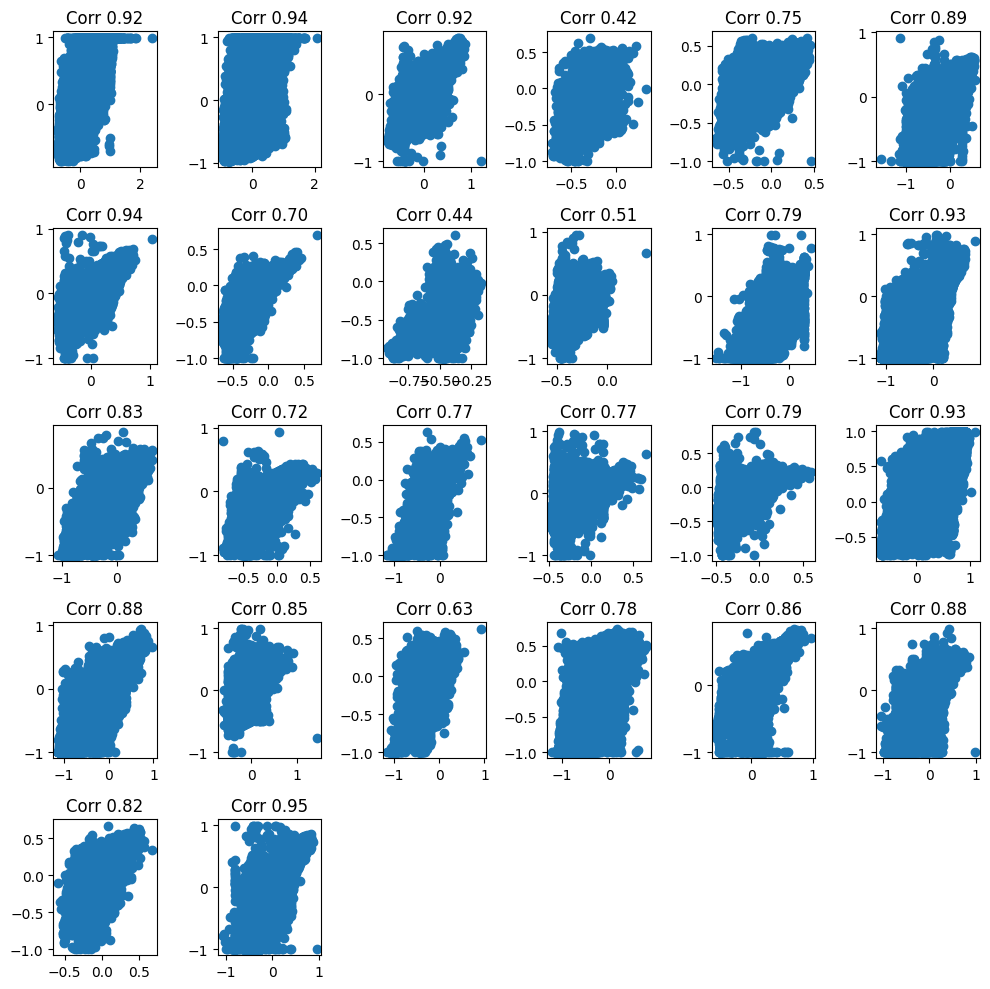

In [87]:
#make a plot of the correlation of each feature
plt.figure(figsize=(10,10))
for i in range(reconstructions.shape[1]):
    plt.subplot(5,6,i+1)
    plt.scatter(reconstructions[:,i],initial_readings[:,i])
    #calculate the correlation
    corr = np.corrcoef(reconstructions[:,i],initial_readings[:,i])[0,1]
    plt.title("Corr {:.2f}".format(corr))
plt.tight_layout()
plt.show()